In [2]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [4]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [5]:
class summarystate(MessagesState):
    summary: str

In [6]:
def chat_node(state: summarystate):

    # print("NUMBER OF MESSAGES:", len(state["messages"]))

    # for i, msg in enumerate(state["messages"]):
    #     print(i, type(msg).__name__, msg.content[:100])

    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation Summary: {state['summary']}"
        })

    messages.extend(state["messages"])

    # print("MESSAGES SENT TO LLM:", len(messages))

    response = LLM.invoke(messages)

    return {"messages": [response]}

In [7]:
def summarry_node(state: summarystate):

    existing_summary = state["summary"]

    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation."
        )
    else:
        prompt = "Summarize the conversation."

    message_for_summary = (
        state["messages"] +
        [HumanMessage(content=prompt)]
    )

    response = LLM.invoke(message_for_summary)

    # Keep only the last 2 messages
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [
            RemoveMessage(id=m.id)
            for m in messages_to_delete
        ]
    }

In [8]:
def should_summarize(state: summarystate):

    print("SHOULD SUMMARIZE CHECK:", len(state["messages"]))

    return len(state["messages"]) >= 6

In [9]:
#building the node
graph = StateGraph(summarystate)

graph.add_node("chat_node", chat_node)
graph.add_node("summarry_node", summarry_node)

graph.add_conditional_edges(
    START,
    should_summarize,
    {
        True: "summarry_node",
        False: "chat_node"
    }
)

graph.add_edge("summarry_node", "chat_node")
graph.add_edge("chat_node", END)


In [10]:
#implementing checkpointer
memory = InMemorySaver()
STM_summarize = graph.compile(checkpointer=memory)


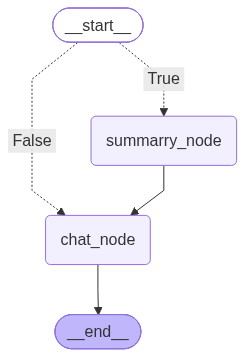

In [11]:
from IPython.display import Image
Image(STM_summarize.get_graph().draw_mermaid_png())

In [12]:
config = {"configurable": {"thread_id": "t1"}}
def run_state(text: str):
    output = STM_summarize.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return output

In [13]:
# gives the current version of the state
def show_state():
    snap = STM_summarize.get_state(config)
    vals = snap.values

    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")

    for m in vals.get("messages", []):
        print(" -", type(m).__name__, ":", m.content[:80])

In [14]:
run_state("ancient egypt")
show_state()

SHOULD SUMMARIZE CHECK: 1

--- STATE ---
summary: 
num_messages: 2
messages:
 - HumanMessage : ancient egypt
 - AIMessage : ## Ancient Egypt – A Quick‑Guide Overview  

### 1. Where & When?
| Aspect | Det


In [15]:
run_state("can you tell me important events in ancient egypt")
show_state()

SHOULD SUMMARIZE CHECK: 3

--- STATE ---
summary: 
num_messages: 4
messages:
 - HumanMessage : ancient egypt
 - AIMessage : ## Ancient Egypt – A Quick‑Guide Overview  

### 1. Where & When?
| Aspect | Det
 - HumanMessage : can you tell me important events in ancient egypt
 - AIMessage : ## Key Events in Ancient Egyptian History  

Below is a **chronological timeline


In [46]:
run_state("during these civilization which ever monuments, tombs, god made name them ")
show_state()

SHOULD SUMMARIZE CHECK: 36


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jrmmana9f02amgrrctc566cg` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 10905, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [45]:
run_state("take out the hostory of cleopetra and tell her reign stroy to me  ")
show_state()

SHOULD SUMMARIZE CHECK: 35


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jrmmana9f02amgrrctc566cg` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 10886, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}